In [2]:
# transformation
# It converts raw data into a usable numerical form.
# It improves data quality and model performance.
# It includes scaling, normalization, and encoding.
# It helps models learn faster and more accurately.
# It reduces noise and inconsistency in data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                       

In [3]:
np.random.seed(0)
df= np.random.exponential(size=1000, scale=2)
df=pd.DataFrame(df, columns=['value'])
df.head()

,value
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='value', ylabel='Count'>

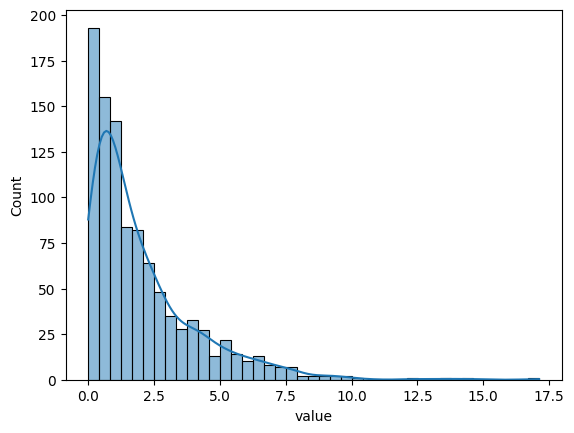

In [5]:
sns.histplot(df['value'], kde=True) 

In [ ]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeojohnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt = QuantileTransformer(output_distribution='normal')

df['boxcox'] = pt_boxcox. fit_transform(df[['value']] + 1)
df['yeojohnson'] = pt_yeojohnson.fit_transform(df[['value']])
df['quantile_normal'] = qt.fit_transform(df[['value']])
# boxcox requires positive data, so we add 1 to 'value' to ensure all values are positive.
# yeojohnson can handle zero and negative values.
# quantile transformer maps data to a normal distribution.

In [7]:
df.head()

,value,boxcox,yeojohnson,quantile_normal
0,1.591749,0.772918,0.787485,0.162552
1,2.511862,0.841253,0.980233,0.587964
2,1.846446,0.794882,0.849553,0.286135
3,1.574402,0.771316,0.782945,0.157469
4,1.102097,0.721316,0.639848,-0.154930


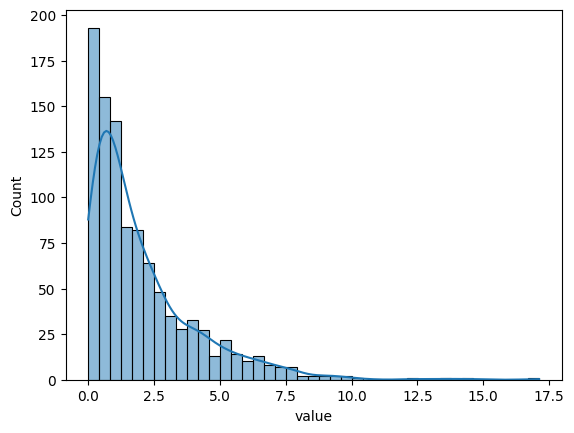

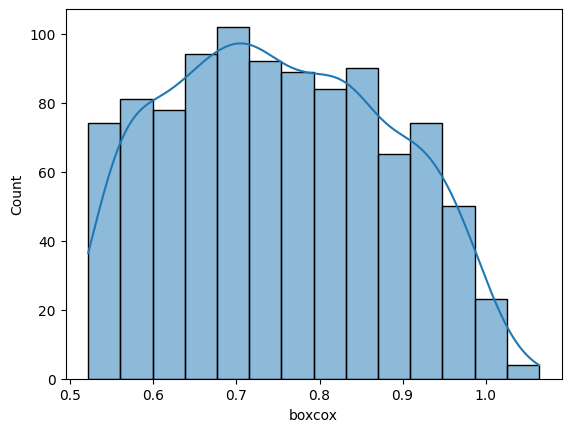

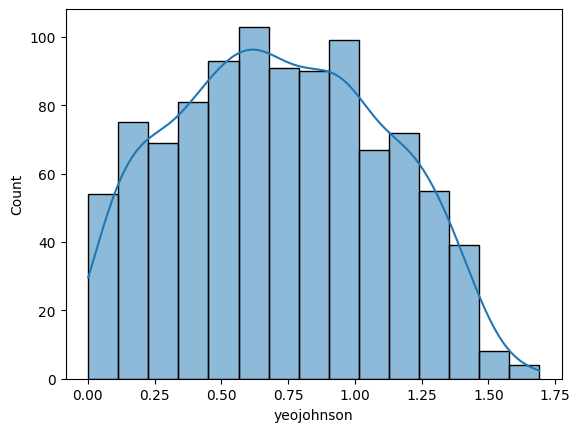

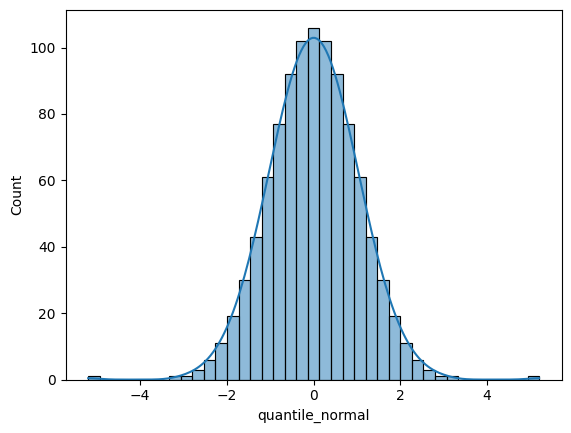

In [8]:
for col in df.columns:# create histogram for each column
    sns.histplot(df[col], kde=True)
    plt.show()

In [15]:
# normalization
# It rescales data to a specific range, usually 0 to 1.
# It ensures all features contribute equally to the model.
# It is useful for algorithms that rely on distance metrics.
# It helps improve model convergence and performance.
# It prevents large-value features from dominating small ones.
# It improves accuracy and training speed of models.
# It is important for distance-based algorithms like KNN and SVM.
# It makes features comparable on the same scale.
# l2 normalization scales data to have a unit norm (length of 1).
# It is useful when the direction of data matters more than magnitude.
# It is commonly used in text classification and clustering tasks.
from sklearn.preprocessing import MinMaxScaler, Normalizer
data=[[1,2,3],[4,5,6],  [7,8,9]] 
normalizer= Normalizer(norm='l2')
print(normalizer.fit_transform(data))

[[0.26726124 0.53452248 0.80178373]
 [0.45584231 0.56980288 0.68376346]
 [0.50257071 0.57436653 0.64616234]]


In [16]:
#l1 normalization scales data so that the sum of absolute values equals 1.
# It is useful when sparsity is desired in the data representation.
# It is commonly used in text processing and feature selection tasks.
# It helps in reducing the impact of outliers.
# It is beneficial for high-dimensional data.
from sklearn.preprocessing import Normalizer
data=[[1,2,3],[4,5,6],  [7,8,9]]
normalizer_l1= Normalizer(norm='l1')
print(normalizer_l1.fit_transform(data))

[[0.16666667 0.33333333 0.5       ]
 [0.26666667 0.33333333 0.4       ]
 [0.29166667 0.33333333 0.375     ]]


In [21]:
#log normalization
# It transforms data using the logarithm function.
# It reduces skewness and stabilizes variance in data.
# It is useful for handling data with exponential growth patterns.
# It helps in visualizing and interpreting data more effectively.
# It is commonly used in financial and scientific data analysis.
data={"values":[1,5,10,50,100,500,1000,5000,10000,50000,100000]}
data=pd.DataFrame(data)
data.head()

,values
0,1
1,5
2,10
3,50
4,100


In [27]:
data['log_normalized']= np.log1p(data['values'])
data

,values,log_normalized
0,1,0.693147
1,5,1.791759
2,10,2.397895
3,50,3.931826
4,100,4.615121
5,500,6.216606
6,1000,6.908755
7,5000,8.517393
8,10000,9.210440
9,50000,10.819798


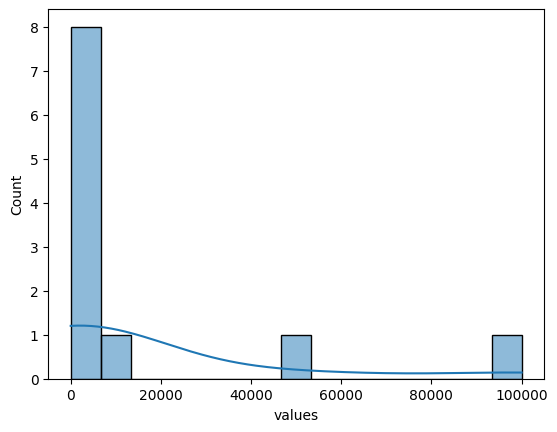

In [30]:
for col in df.columns:# create histogram for each column
    sns.histplot(df[col], kde=True)
    plt.show()

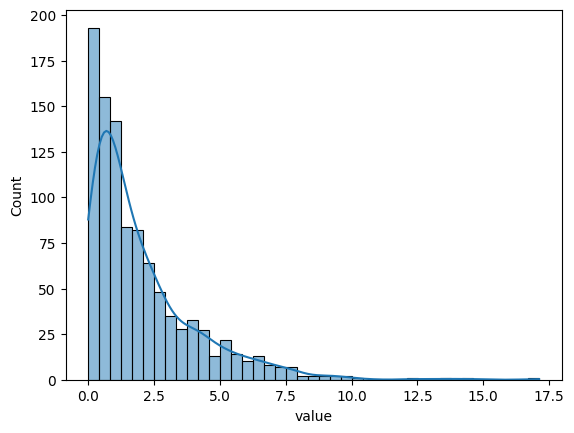

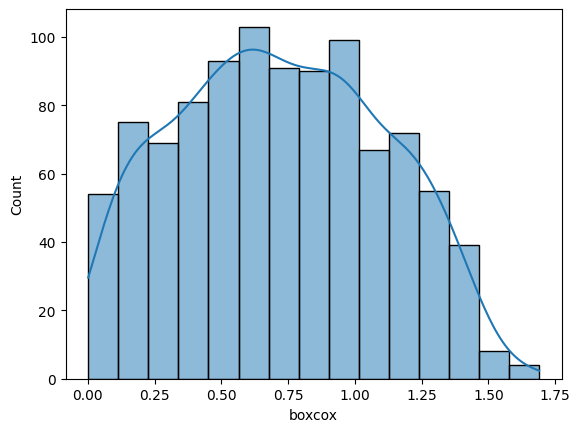

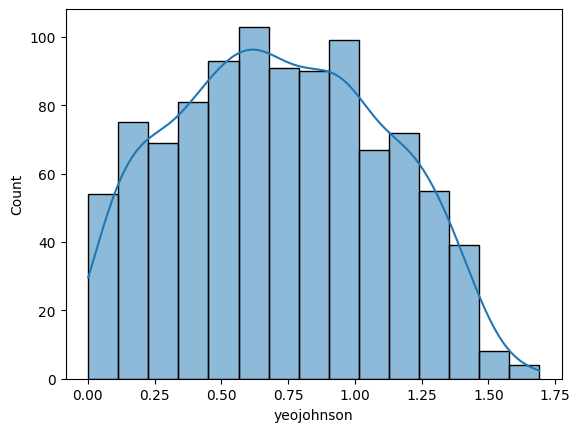

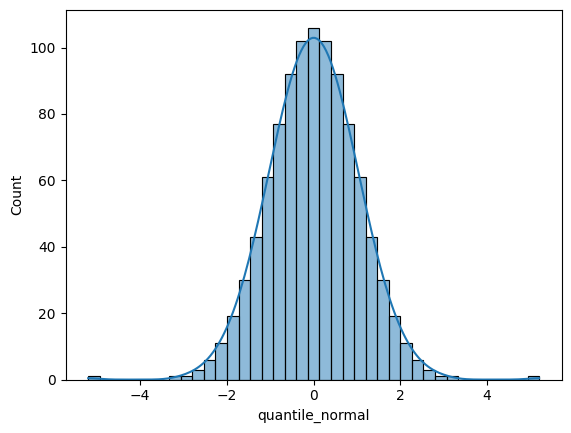

In [ ]:
#pipline of transformations
# It combines multiple transformation steps into a single process.
# It ensures consistent application of transformations during training and testing.
# It simplifies code and improves maintainability.
# It helps prevent data leakage by applying transformations correctly.
# It enhances reproducibility of results.

#code
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, Normalizer
# Sample data
np.random.seed(0)   
df= np.random.exponential(size=1000, scale=2)
df=pd.DataFrame(df, columns=['value'])
# Transformation    
pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeojohnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt = QuantileTransformer(output_distribution='normal')
df['boxcox'] = pt_boxcox. fit_transform(df[['value']] + 1)
df['yeojohnson'] = pt_yeojohnson.fit_transform(df[['value
]])
df['quantile_normal'] = qt.fit_transform(df[['value']])

# Visualization
for col in df.columns:# create histogram for each column
    sns.histplot(df[col], kde=True)
    plt.show()

        